In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
# imports
from matplotlib import pyplot as plt
import numpy as np
import sympy as sp
import torch
import os
import arviz as az
import pyro
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

from equayes import Equayes, PROJECT_ROOT
from equayes.core.pyro_backend import utils as pyro_utils
from equayes.visualisation import predictive_plotting as pred_plot

Text(0, 0.5, 'y')

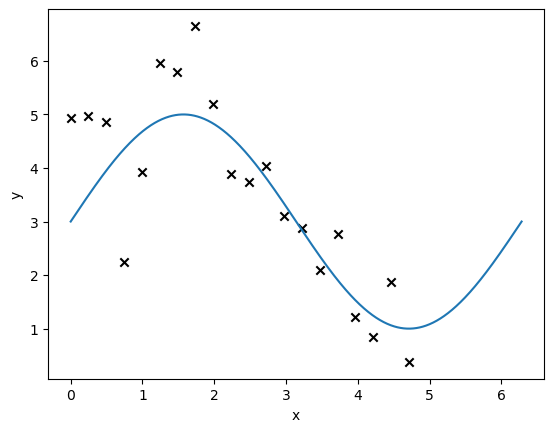

In [3]:
# create data
N_train = 20
N_test = 1000
seed = 42

noise_sigma = 1.  
np.random.seed(seed)
torch.manual_seed(seed)

def synthetic_function_1d(x, noise_sigma=1.):
    y = 2 * torch.sin(x) + 3
    y_obs = y + torch.randn(x.shape if len(x) > 0 else (1,)) * noise_sigma
    return y, y_obs


x_train = torch.linspace(0, 3*np.pi/2, steps=N_train)
x_test = torch.linspace(0, 4*np.pi/2, steps=N_test)

y_train, y_obs_train = synthetic_function_1d(x_train, noise_sigma)
y_test, y_obs_test = synthetic_function_1d(x_test, noise_sigma)

plt.scatter(x_train, y_obs_train, marker="x", color="black")
plt.plot(x_test, y_test, label="True Function")
plt.xlabel("x")
plt.ylabel("y")


In [10]:
# Do post-hoc Inference on the given Sympy equation string.

# define sympy expression
x0 = sp.Symbol('x0')

expr_sp_true = 2. * sp.sin(x0) + 3.
expr_sp_quadratic = 2. * x0**2 - 1.1 * x0 + 5.

kernel = "nuts"

print("Ground truth")
print(sp.sympify(expr_sp_true))
print("Quadratic Function")
print(sp.sympify(expr_sp_quadratic))

equayes = Equayes(
    expr=expr_sp_quadratic,
    input_symbols=[x0],
    output_dim=1,
    inference_params={"kernel_name": f"{kernel}", "n_warmup_samples":10, "n_samples":10}
)


equayes.fit(x_train.view((-1,1)), y_obs_train.view((-1,1)))


Ground truth
2.0*sin(x0) + 3.0
Quadratic Function
2.0*x0**2 - 1.1*x0 + 5.0


Sample: 100%|██████████| 20/20 [00:01, 18.04it/s, step size=4.63e-02, acc. prob=0.136]


In [11]:
equayes.predict(x_train.view((-1,1)), sample_prior=False, parallel=True)["mu"].shape


torch.Size([500, 1, 20, 1])


                 mean       std    median      5.0%     95.0%     n_eff     r_hat
 epsilon[0]      1.10      0.09      1.05      1.05      1.33     13.19      0.94
theta_p0[0]      4.62      0.22      4.74      4.22      4.76      3.82      1.39
theta_p1[0]     -0.22      0.03     -0.22     -0.29     -0.17      8.52      0.90
theta_p2[0]      0.15      0.12      0.08      0.07      0.39      5.15      1.08

Number of divergences: 2


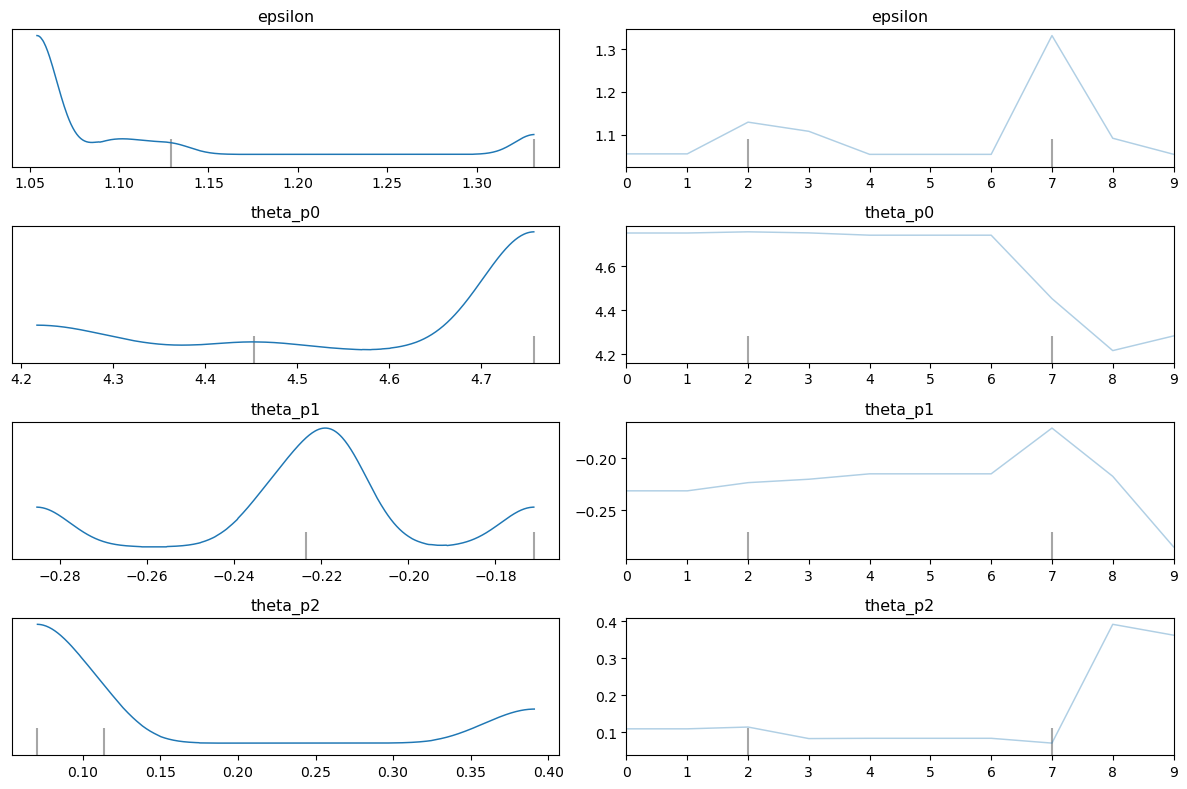

In [12]:
# Evaluation
os.makedirs(f"{PROJECT_ROOT}/output", exist_ok=True)

equayes.inference_diagnostics()

idata = equayes.get_posterior()
if type(idata) is not az.InferenceData:
    idata = pyro_utils.guide_to_inference_data(equayes._pyro_model, equayes._guide, x_train.view((-1,1)), num_samples=3000)

az.plot_trace(idata)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/output/posterior_{kernel}.png")
# 

In [14]:
idata

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

torch.Size([500, 1, 1000, 1])


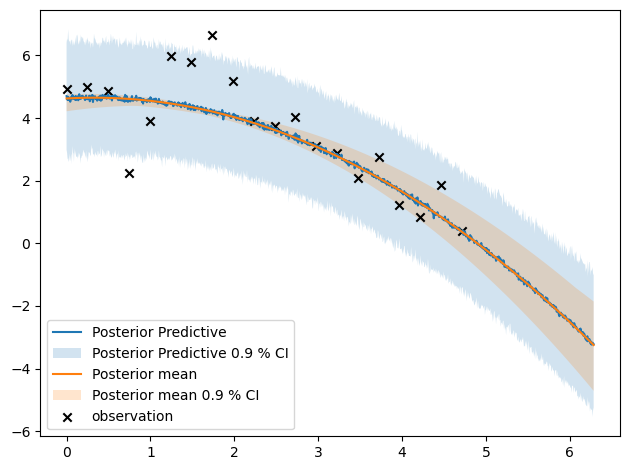

In [16]:


pred_samples = equayes.predict(x_test.view(-1,1), n_predictive_samples=500, parallel=True)
print(pred_samples["mu"].shape)
ax = pred_plot.plot_1d_predictive_density(x_test.numpy(), pred_samples["obs"].squeeze().numpy(), label="Posterior Predictive")
ax = pred_plot.plot_1d_predictive_density(x_test.numpy(), pred_samples["mu"].squeeze().numpy(), label="Posterior mean", ax=ax)

ax.scatter(x_train, y_obs_train, marker="x", color="black", label="observation")

plt.legend()
plt.tight_layout()

plt.savefig(f"{PROJECT_ROOT}/output/post_pred_{kernel}.png")